# Train YOLO11n on the ROD-Dataset

**Real-Time Obstacle Detection** — 25 classes, ~24,326 images.
Dataset: https://www.kaggle.com/datasets/abtinzandi/obstacle-detection-dataset

From the creator's notebook on training YOLO11n (https://www.kaggle.com/code/ariyanazami/train-yolo11n-on-the-rod-dataset#5-%C2%B7-Validate-on-the-held-out-test-split), they achieve the following metrics:
* MmAP@50: 0.890
* mAP@50-95: 0.735
* Precision: 0.916
* Recall: 0.872 => Good — missing ~13% of real objects
* FPS70: Fast, deployment-friendly

From the evaluation graphs:
* Training Curves show no overfitting.
* Confusion Matrix: The model learns very well Bike, Building, Traffic Sign, Electrical Pole, Dog, Manhole, Traffic Cone, Fire Hydrant, Teraffic Barrel, Electrical Box; but not really well on Dustbin (0.69), Motorcycle (0.7), Truck (0.8), and Bicycle Rack (0.8)

=> Let's try to see if finetuning could improve Recall to at least 0.9, and could improve on these classes

## 1 · Config

In [1]:
# ============================ CONFIG ============================
MODEL_VARIANT = "yolov11n"           # which model this notebook trains
WEIGHTS       = "yolo11n.pt"     # pretrained checkpoint to fine-tune from

EPOCHS   = 150        # 100 -> 150 ~ longer training
BATCH    = 128        # TOTAL images per step, split across GPUs (64/GPU on 2x T4)
IMGSZ    = 640        # train/val image size
DEVICE   = "0,1"      # use BOTH T4 GPUs for training (DDP). Set to 0 for one GPU.
EVAL_DEVICE = 0       # val/predict/benchmark always run on a single GPU
PATIENCE = 30         # 20 -> 30 to give more room before early stopping
COS_LR   = True       # cosine LR schedule
SEED     = 42

CONF     = 0.15       # 0.25 -> 0.15 (lower to catch more true objects)
IOU      = 0.7        # NMS IoU threshold

PROJECT  = "/kaggle/working/runs"
RUN_NAME = f"rod_{MODEL_VARIANT}"
# ===============================================================
print(f"Training {MODEL_VARIANT} from {WEIGHTS} | {EPOCHS} epochs | batch {BATCH} | imgsz {IMGSZ} | device {DEVICE}")

Training yolov11n from yolo11n.pt | 150 epochs | batch 128 | imgsz 640 | device 0,1


## 2 · Install & environment check

In [2]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [3]:
import torch, ultralytics
print("ultralytics:", ultralytics.__version__)
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  ({total/1e9:.0f} GB)")

# Auto-correct DEVICE if fewer GPUs are available than requested (e.g. P100 x1 instead of T4 x2)
if isinstance(DEVICE, str) and "," in DEVICE:
    requested = len(DEVICE.split(","))
    available = torch.cuda.device_count()
    if available < requested:
        DEVICE = ",".join(str(i) for i in range(available)) if available > 0 else "cpu"
        print(f"WARNING: Only {available} GPU(s) available — DEVICE overridden to '{DEVICE}'")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.71
torch: 2.10.0+cu128 | CUDA available: True
  GPU 0: Tesla T4  (16 GB)
  GPU 1: Tesla T4  (16 GB)


## 3 · Locate the dataset & write a fresh `data.yaml`

`/kaggle/input/` is read-only and the mount path differs per dataset version, so
we search for the dataset's own `data.yaml`, then write a corrected copy into
`/kaggle/working/` with absolute split paths.

In [4]:
import yaml
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
src = next((p for p in INPUT_ROOT.rglob("data.yaml")), None)
assert src is not None, "data.yaml not found under /kaggle/input — did you Add the dataset?"
data_root = src.parent
print("Dataset root:", data_root)

with open(src) as f:
    orig = yaml.safe_load(f)

data_yaml = {
    "path":  str(data_root),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    orig["nc"],
    "names": orig["names"],
}
DATA = "/kaggle/working/data.yaml"
with open(DATA, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("Wrote", DATA, "|", data_yaml["nc"], "classes")
print(data_yaml["names"])

Dataset root: /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset
Wrote /kaggle/working/data.yaml | 25 classes
['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree', 'Guard rail', 'Pedestrian crosswalk', 'Truck', 'Bus', 'Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']


## 4 · Train

By default `DEVICE = "0,1"` trains on **both** T4s via PyTorch DDP (`BATCH` is the
total, split across GPUs). If DDP misbehaves in the notebook, set `DEVICE = 0` to
fall back to a single GPU. The dataset is a *detect-segment mixed* set —
Ultralytics keeps the boxes and drops segments automatically (you'll see a
one-time warning, which is expected).

In [5]:
from ultralytics import YOLO

model = YOLO(WEIGHTS)
results = model.train(
    data     = DATA,
    task     = "detect",
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    device   = DEVICE,
    amp      = True,
    cache    = False,
    workers  = 4,
    project  = PROJECT,
    name     = RUN_NAME,
    patience = PATIENCE,
    cos_lr   = COS_LR,
    plots    = True,
    seed     = SEED,
)
# Multi-GPU DDP training in a notebook relaunches as a subprocess and returns
# None in the parent process, so `results` may be None even though training
# finished. Fall back to locating the run directory under PROJECT/RUN_NAME.
if results is not None and getattr(results, "save_dir", None):
    RUN_DIR = Path(results.save_dir)
else:
    candidates = sorted(Path(PROJECT).glob(RUN_NAME + "*"),
                        key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise RuntimeError(f"No run directory found under {PROJECT}/{RUN_NAME}*")
    RUN_DIR = candidates[-1]
print("Run dir:", RUN_DIR)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rod_yolov11n, nbs=64, n

## 5 · Validate on the held-out **test** split

We reload `best.pt` (more reliable than reusing the live training object) and
run `val()` on the test split — this reports mAP50, mAP50-95, precision, recall
and writes confusion matrices + PR/F1 curves.

In [6]:
best = RUN_DIR / "weights" / "best.pt"
eval_model = YOLO(str(best))

metrics = eval_model.val(
    data   = DATA,
    task   = "detect",
    split  = "test",
    imgsz  = IMGSZ,
    batch  = BATCH,
    device = EVAL_DEVICE,   # validate on a single GPU (DDP val in notebooks is flaky)
    conf   = CONF,
    iou    = IOU,
    plots  = True,
)
VAL_DIR = Path(metrics.save_dir)
print(metrics.results_dict)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,587,027 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6.2±2.1 MB/s, size: 35.9 KB)
val: Scanning /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/test/labels... 1629 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1629/1629 207.5it/s 7.8s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/test is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 416, len(boxes) = 2372. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.3s/it 17.0s1.1s
  

## 6 · Inference speed benchmark (latency / FPS)

Warm up, then time `predict()` over the whole test set — the same methodology as
the project's `time_inference.py`.

In [7]:
import time, glob

def benchmark(m, image_paths, imgsz, device=0, conf=0.25, iou=0.7, batch=8, warmup=5):
    for p in image_paths[:warmup]:
        _ = m.predict(p, imgsz=imgsz, device=device, conf=conf, iou=iou, verbose=False)
    t0 = time.perf_counter(); n = 0
    for i in range(0, len(image_paths), batch):
        chunk = image_paths[i:i + batch]
        _ = m.predict(chunk, imgsz=imgsz, device=device, conf=conf, iou=iou, verbose=False)
        n += len(chunk)
    dt = time.perf_counter() - t0
    return (dt / n) * 1000.0, n / dt, dt

test_imgs = sorted(glob.glob(str(data_root / "test/images/*.jpg")))
avg_ms, fps, total_s = benchmark(eval_model, test_imgs, IMGSZ, device=EVAL_DEVICE,
                                 conf=CONF, iou=IOU, batch=BATCH)
print(f"{avg_ms:.2f} ms/img | {fps:.1f} FPS | {total_s:.1f}s over {len(test_imgs)} images")

13.09 ms/img | 76.4 FPS | 21.3s over 1629 images


## 7 · Save a machine-readable summary

Writes `<variant>_summary.json` and `<variant>_results.txt` to
`/kaggle/working/` so the **compare** notebook can chart every model side by
side, and viewers can download the numbers.

In [8]:
import json
from datetime import datetime

rd = metrics.results_dict
summary = {
    "model":          MODEL_VARIANT,
    "weights":        str(best),
    "timestamp":      datetime.now().isoformat(timespec="seconds"),
    "epochs":         EPOCHS,
    "imgsz":          IMGSZ,
    "batch":          BATCH,
    "params":         int(sum(p.numel() for p in eval_model.model.parameters())),
    "mAP50_95":       rd.get("metrics/mAP50-95(B)"),
    "mAP50":          rd.get("metrics/mAP50(B)"),
    "precision":      rd.get("metrics/precision(B)"),
    "recall":         rd.get("metrics/recall(B)"),
    "avg_ms_per_img": round(avg_ms, 3),
    "fps":            round(fps, 2),
    "test_images":    len(test_imgs),
}
out_json = Path("/kaggle/working") / f"{MODEL_VARIANT}_summary.json"
out_json.write_text(json.dumps(summary, indent=2))
out_txt = Path("/kaggle/working") / f"{MODEL_VARIANT}_results.txt"
out_txt.write_text("\n".join(f"{k}: {v}" for k, v in summary.items()))
print(json.dumps(summary, indent=2))

{
  "model": "yolov11n",
  "weights": "/kaggle/working/runs/rod_yolov11n/weights/best.pt",
  "timestamp": "2026-06-19T20:27:27",
  "epochs": 150,
  "imgsz": 640,
  "batch": 128,
  "params": 2587027,
  "mAP50_95": 0.7468397260425748,
  "mAP50": 0.8973993725788486,
  "precision": 0.9158748989755695,
  "recall": 0.8795825535606283,
  "avg_ms_per_img": 13.094,
  "fps": 76.37,
  "test_images": 1629
}


## 8 · Training & evaluation graphs

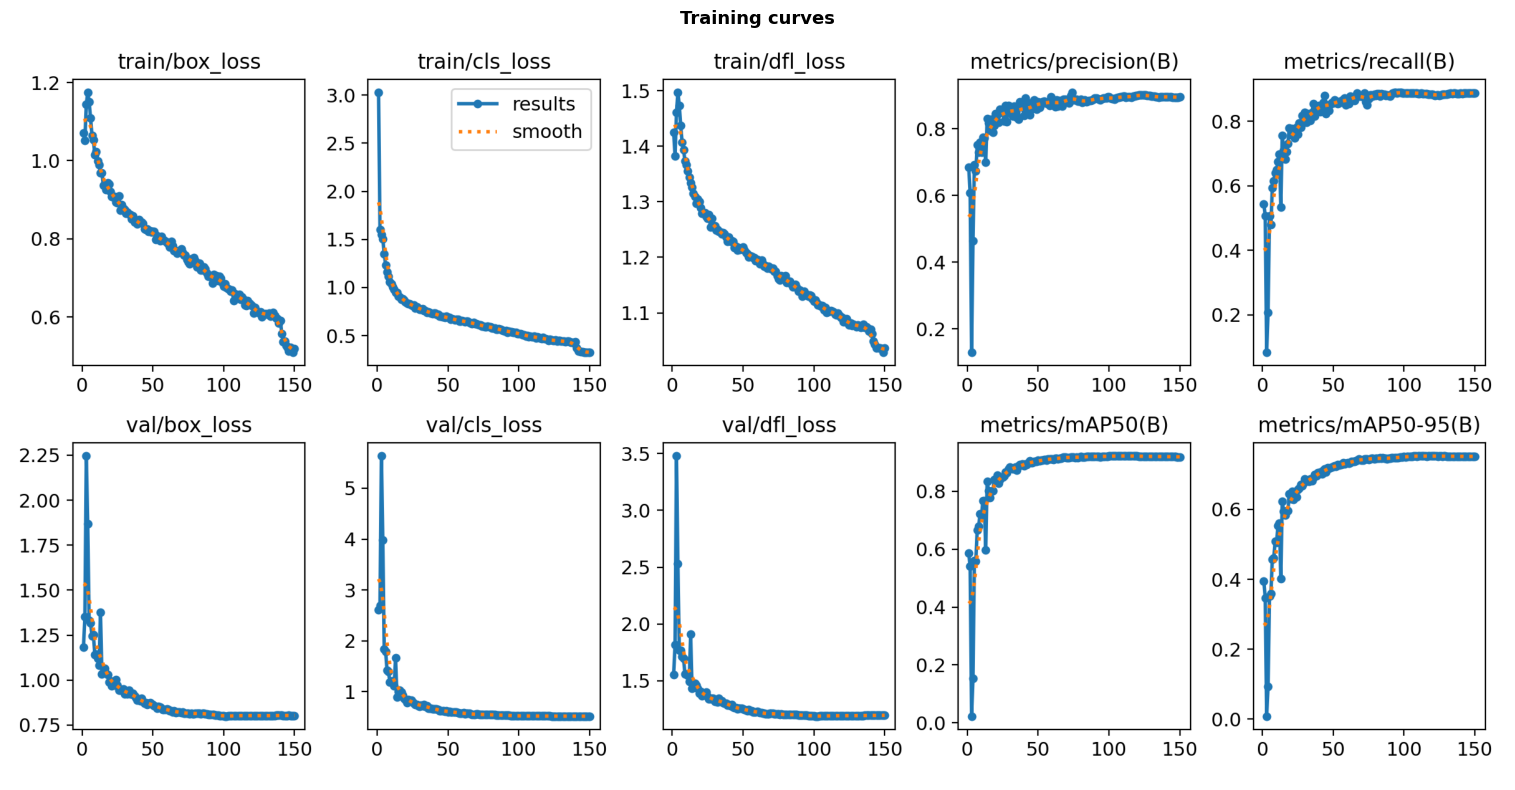

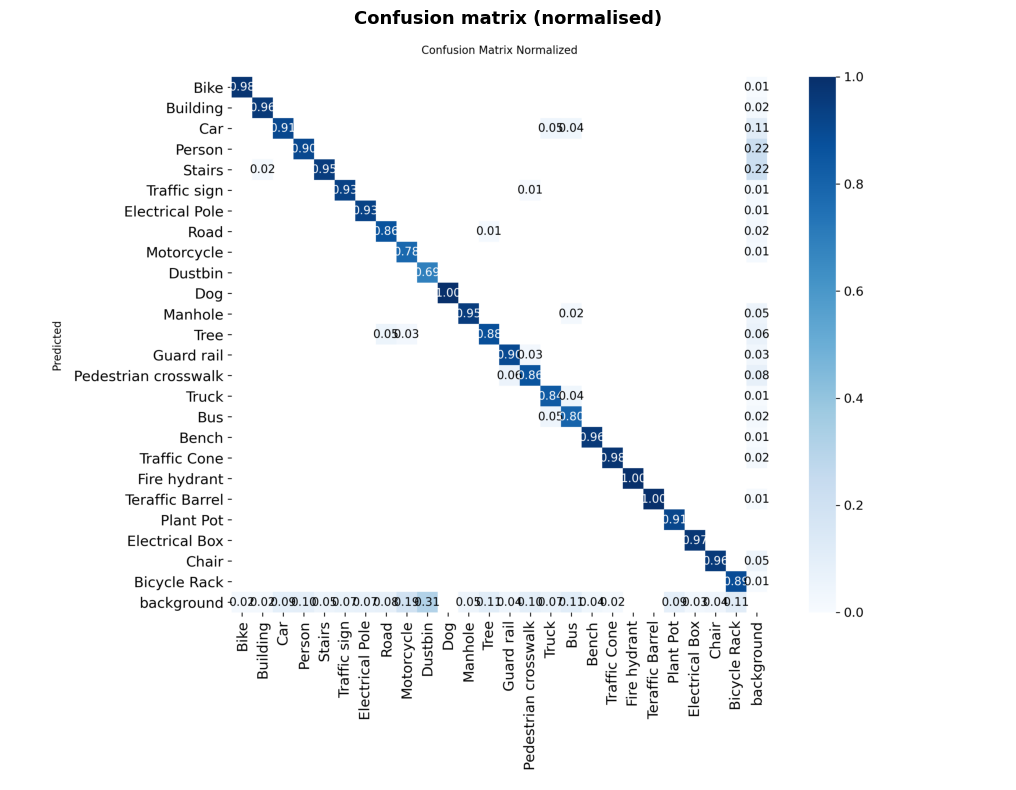

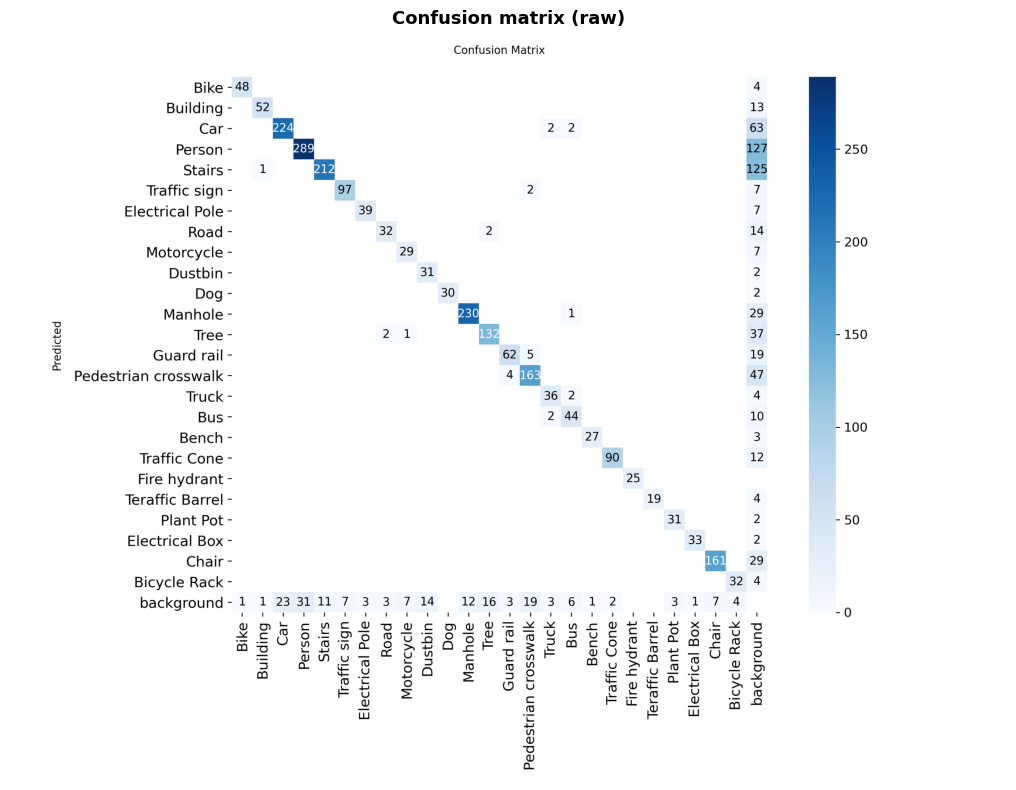

[skip] PR_curve.png not found
[skip] F1_curve.png not found
[skip] P_curve.png not found
[skip] R_curve.png not found


In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show(path, title=""):
    path = Path(path)
    if not path.exists():
        print("[skip]", path.name, "not found"); return
    plt.figure(figsize=(16, 8))
    plt.imshow(mpimg.imread(str(path)))
    plt.axis("off")
    if title:
        plt.title(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

show(RUN_DIR / "results.png",                     "Training curves")
show(VAL_DIR / "confusion_matrix_normalized.png", "Confusion matrix (normalised)")
show(VAL_DIR / "confusion_matrix.png",            "Confusion matrix (raw)")
show(VAL_DIR / "PR_curve.png",                    "Precision-Recall curve")
show(VAL_DIR / "F1_curve.png",                    "F1-Confidence curve")
show(VAL_DIR / "P_curve.png",                     "Precision-Confidence curve")
show(VAL_DIR / "R_curve.png",                     "Recall-Confidence curve")

## 9 · Predictions on sample test images

Results saved to /kaggle/working/runs/predict


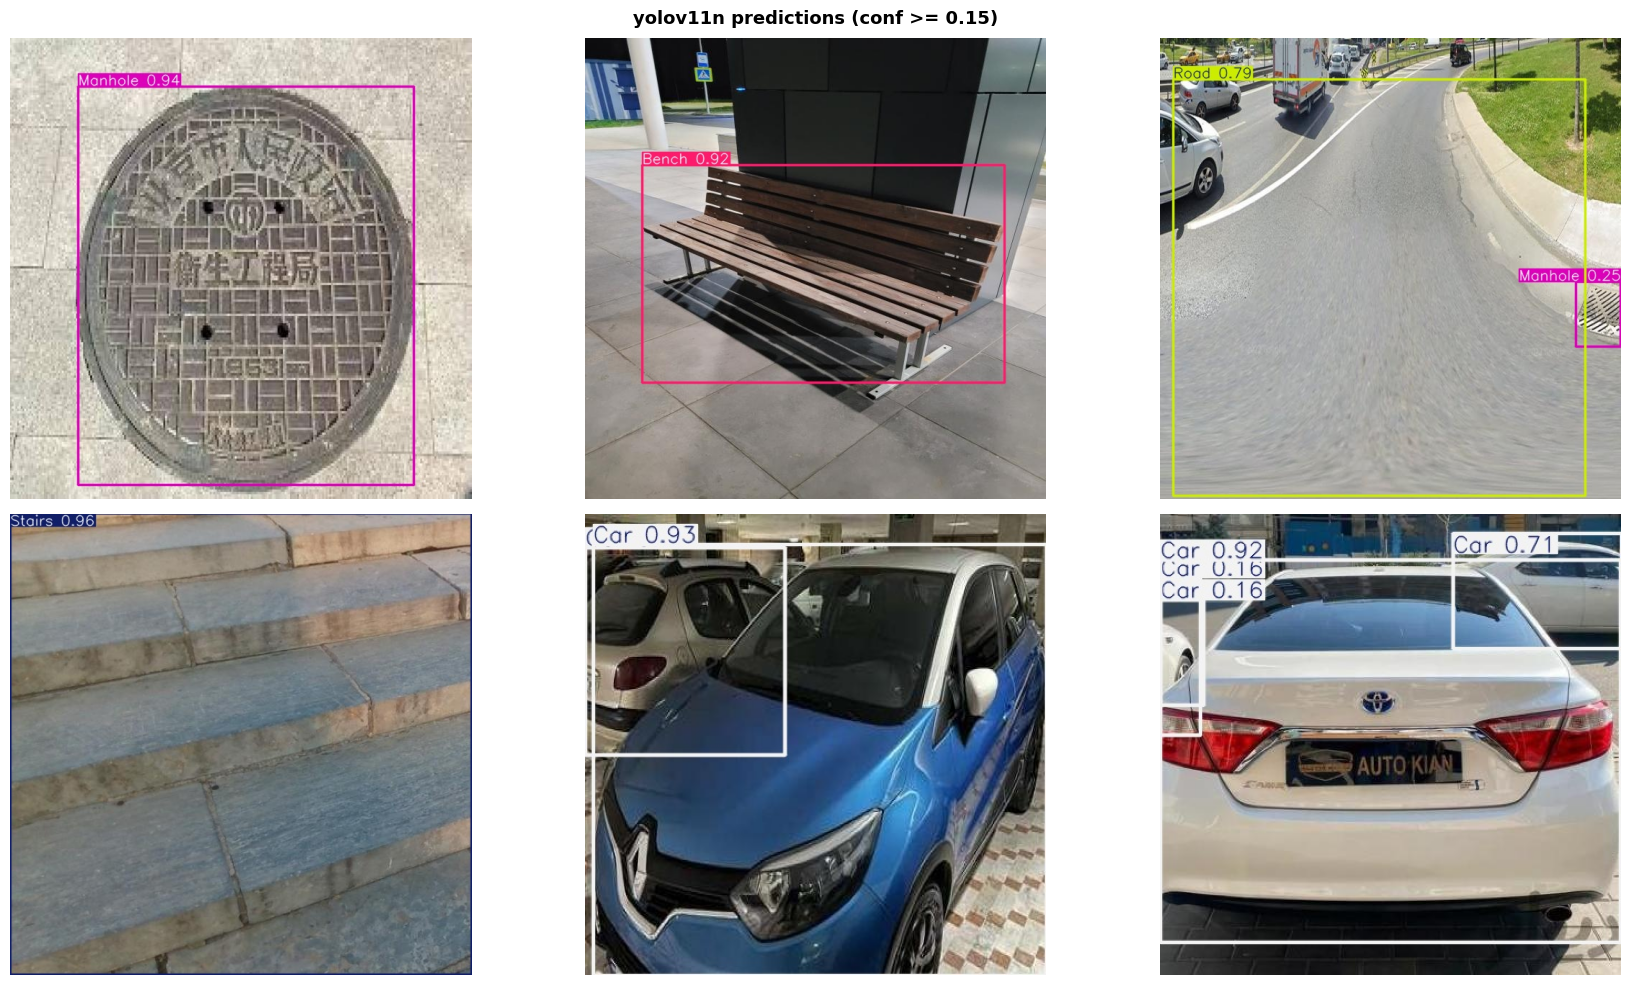

In [10]:
import random
random.seed(SEED)
samples = random.sample(test_imgs, min(6, len(test_imgs)))

eval_model.predict(samples, imgsz=IMGSZ, conf=CONF, device=EVAL_DEVICE, save=True,
                   project=PROJECT, name="predict", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
pred_imgs = sorted(glob.glob(f"{PROJECT}/predict/*.jpg"))[:6]
for ax, p in zip(axes.flat, pred_imgs):
    ax.imshow(mpimg.imread(p)); ax.axis("off")
for ax in axes.flat[len(pred_imgs):]:
    ax.axis("off")
plt.suptitle(f"{MODEL_VARIANT} predictions (conf >= {CONF})", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 10 · Save weights for download

In [11]:
import shutil
for w in (RUN_DIR / "weights" / "best.pt", RUN_DIR / "weights" / "last.pt"):
    if w.exists():
        dst = Path("/kaggle/working") / f"{MODEL_VARIANT}_{w.name}"
        shutil.copy(str(w), str(dst))
        print("Saved", dst)

Saved /kaggle/working/yolov11n_best.pt
Saved /kaggle/working/yolov11n_last.pt


## 11 · (Optional) Export for mobile / edge

Uncomment what you need. Mirrors the deployment formats used by the ROD project
(ONNX for desktop, TFLite/NCNN for Android).

In [12]:
eval_model.export(format="onnx",  imgsz=IMGSZ, opset=12)
# eval_model.export(format="tflite", imgsz=320, int8=True)
# eval_model.export(format="ncnn",  imgsz=320)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/rod_yolov11n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 29, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 375ms
Prepared 2 packages in 349ms
Installed 2 packages in 17ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.1s, saved as '/kaggle/working/runs/rod_yolov11n/weights/best.onnx' (10.1 MB)

Export co

'/kaggle/working/runs/rod_yolov11n/weights/best.onnx'